#Evaluation: Traditional LSTM vs Generative LLM

In this notebook, we load the centrally trained models (`lstm_baseline.pt` and `t5_semantic.pt`) and evaluate them side-by-side on 3 random sentences from the Europarl dataset across 6 different SNR conditions.

We generate two output tables:
1. **Sample-by-Sample Generation** (18 rows) to visually inspect the hallucination and semantic reconstruction.
2. **Aggregated Evaluation Metrics** (12 rows) comparing average BLEU, WER, ROUGE, and Cosine Intent across models at each SNR.

In [15]:
import sys
import os
import torch
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import T5Tokenizer
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import jiwer
sys.path.append(os.path.abspath(r'C:\Users\Shrish\Desktop\semantic-comm\actual_project'))
from src.data_loader import EuroparlDataLoader
from src.tokenizer import SemanticTokenizer
from src.model import JointSemanticModel
from src.llm_model import GenerativeSemanticModel

print("loaded.")

loaded.


###load the weightss
refer to the weights stored in model directory , ek baar train kar lena , 10-12 ghnte lagenge 

In [16]:

# IMPORTANT: We must load exactly 30,000 sentences because the LSTM baseline was trained on 30,000.
#rebuilding lstm vocab , and size of weight matrix must match so 300000 must not be changed
data_dir = r"C:\Users\Shrish\Desktop\semantic-comm\Semantic_Communication\europarl\en\en"
loader = EuroparlDataLoader(data_dir=data_dir, target_sentences=30000)
loader.scan_and_load()
sentences = loader.all_sentences if len(loader.all_sentences) > 0 else ["The future is semantic communication."] * 1000

lstm_tokenizer = SemanticTokenizer(min_freq=2)
lstm_tokenizer.fit(sentences)
print(f"LSTM Vocab Rebuilt: {lstm_tokenizer.vocab_size} tokens.")

llm_tokenizer = T5Tokenizer.from_pretrained("t5-small")
print("T5 Tokenizer loaded.")

#LSTM Model
lstm_model = JointSemanticModel(vocab_size=lstm_tokenizer.vocab_size, embed_dim=128, hidden_dim=256, snr_db=10.0)
lstm_path = os.path.abspath(r"C:\Users\Shrish\Desktop\semantic-comm\actual_project\models\lstm_baseline.pt")
if os.path.exists(lstm_path):
    lstm_model.load_state_dict(torch.load(lstm_path, map_location="cpu", weights_only=True))
    print("LSTM Weights loaded.")
lstm_model.eval()

#LLM Model
llm_model = GenerativeSemanticModel(model_name="t5-small", snr_db=10.0)
llm_path = os.path.abspath(r"C:\Users\Shrish\Desktop\semantic-comm\actual_project\models\t5_semantic.pt")
if os.path.exists(llm_path):
    llm_model.load_state_dict(torch.load(llm_path, map_location="cpu", weights_only=True))
    print("T5 LLM Weights loaded.")
llm_model.eval()

Scanning dataset to build vocabulary...
dictionary size: 20244
LSTM Vocab Rebuilt: 20244 tokens.
T5 Tokenizer loaded.
LSTM Weights loaded.


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

T5 LLM Weights loaded.


GenerativeSemanticModel(
  (t5): T5ForConditionalGeneration(
    (shared): Embedding(32128, 512)
    (encoder): T5Stack(
      (embed_tokens): Embedding(32128, 512)
      (block): ModuleList(
        (0): T5Block(
          (layer): ModuleList(
            (0): T5LayerSelfAttention(
              (SelfAttention): T5Attention(
                (q): Linear(in_features=512, out_features=512, bias=False)
                (k): Linear(in_features=512, out_features=512, bias=False)
                (v): Linear(in_features=512, out_features=512, bias=False)
                (o): Linear(in_features=512, out_features=512, bias=False)
                (relative_attention_bias): Embedding(32, 8)
              )
              (layer_norm): T5LayerNorm()
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (1): T5LayerFF(
              (DenseReluDense): T5DenseActDense(
                (wi): Linear(in_features=512, out_features=2048, bias=False)
                (wo): Linear(in

###3 Random Test Sentences
for testing purpose, train loss

In [17]:
random.seed(42)
test_sentences = random.sample(sentences, 3)
for i, s in enumerate(test_sentences):
    print(f"[{i}] {s}")

[0] We decided at that conference that we must try to adjust the Union' s action plan to the candidate States, too, and try to accumulate experience with a view to combating the threat of discrepancies arising between different countries.
[1] After investigating these complaints between 1998 and the beginning of 1999 - during which time the project did not receive support from the Structural Funds - the Commission became convinced, in the summer of 1999, that the relevant protection criteria had been observed during the building of the harbour. An in-depth environmental impact assessment had been carried out. The most serious harm caused by the project, the damage to the Stegrennan mudflats, was only to be temporary, and the developers were liable for completely restoring the mudflats.
[2] I have no objection to examining an amendment making Community law stricter but, as other members have stressed, we need to start with application, because there is already a legal framework at Europ

###Running the Multi-SNR Sweep
We will push all 3 sentences through both the LSTM and T5 models at 6 different SNRs.
We also calculate BLEU, WER, and ROUGE concurrently.

In [18]:
def calculate_wer(ref, hyp):
    if not ref.strip() or not hyp.strip(): return 1.0
    return jiwer.wer(ref, hyp)

rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
smoothie = SmoothingFunction().method1

snr_levels = [15.0, 10.0, 5.0, -5.0, -10.0, -15.0]

output_data = []
metrics_data = []


for snr in snr_levels:
    print(f"\nSNR: {snr} dB ")
    
    lstm_bleu, lstm_wer, lstm_rouge = 0, 0, 0
    llm_bleu, llm_wer, llm_rouge = 0, 0, 0
    
    for idx, sentence in enumerate(test_sentences):
       
        lstm_tokens = lstm_tokenizer.encode(sentence, max_length=20)
        lstm_tensor = torch.tensor([lstm_tokens], dtype=torch.long)
        
        with torch.no_grad():
            _, (h, c) = lstm_model.encoder.lstm(lstm_model.encoder.embedding(lstm_tensor))
            noisy_h = lstm_model.channel(h, snr_db_override=snr)
            noisy_c = lstm_model.channel(c, snr_db_override=snr)
            
            input_step = torch.tensor([[lstm_tokenizer.BOS_ID]], dtype=torch.long)
            pred_tokens = []
            for _ in range(20):
                pred, noisy_h, noisy_c = lstm_model.decoder(input_step, noisy_h, noisy_c)
                pred_id = torch.argmax(pred, dim=1).item()
                if pred_id == lstm_tokenizer.EOS_ID: break
                pred_tokens.append(pred_id)
                input_step = torch.tensor([[pred_id]], dtype=torch.long)
                
        lstm_output = lstm_tokenizer.decode(pred_tokens)
        
       
        llm_inputs = llm_tokenizer(sentence, return_tensors="pt", max_length=20, truncation=True)
        with torch.no_grad():
            # Uses the custom generate loop built in llm_model.py
            llm_gen_ids = llm_model.generate(llm_inputs["input_ids"], attention_mask=llm_inputs["attention_mask"], snr_override=snr, max_length=20)
            llm_output = llm_tokenizer.decode(llm_gen_ids[0], skip_special_tokens=True)
            
        
        verdict = "LLM reads cleaner with similar semantic ." if len(llm_output) > len(lstm_output) else "Comparable Degradation."
        
        output_data.append({
            "SNR (dB)": snr,
            "ID": idx,
            "Input Sentence": sentence,
            "Traditional Output": lstm_output,
            "LLM Output": llm_output,
            "Verdict": verdict
        })
        
        ref_tok = sentence.split()
        lstm_bleu += sentence_bleu([ref_tok], lstm_output.split(), smoothing_function=smoothie)
        lstm_wer += calculate_wer(sentence, lstm_output)
        lstm_rouge += rouge.score(sentence, lstm_output)['rougeL'].fmeasure
        
        llm_bleu += sentence_bleu([ref_tok], llm_output.split(), smoothing_function=smoothie)
        llm_wer += calculate_wer(sentence, llm_output)
        llm_rouge += rouge.score(sentence, llm_output)['rougeL'].fmeasure
        
    
    metrics_data.append({"SNR (dB)": snr, "Model": "Traditional", "Avg BLEU": lstm_bleu/3, "Avg WER": lstm_wer/3, "Avg NLP (ROUGE)": lstm_rouge/3})
    metrics_data.append({"SNR (dB)": snr, "Model": "LLM", "Avg BLEU": llm_bleu/3, "Avg WER": llm_wer/3, "Avg NLP (ROUGE)": llm_rouge/3})
    
print("\ndone")


SNR: 15.0 dB 

SNR: 10.0 dB 

SNR: 5.0 dB 

SNR: -5.0 dB 

SNR: -10.0 dB 

SNR: -15.0 dB 

done


### The Results

#### Table 1: Output Matrix (18 Rows)

In [19]:
pd.set_option('display.max_colwidth', None)
df_outputs = pd.DataFrame(output_data)


styled_df = df_outputs.style.set_properties(**{
    'text-align': 'left', 
    'white-space': 'pre-wrap', 
    'word-wrap': 'break-word'
})
display(styled_df)

,SNR (dB),ID,Input Sentence,Traditional Output,LLM Output,Verdict
0,15.000000,0,"We decided at that conference that we must try to adjust the Union' s action plan to the candidate States, too, and try to accumulate experience with a view to combating the threat of discrepancies arising between different countries.","you that will the that will be to that in, of, the to the of has to a",We decided at that conference that we must try to adjust the Union' s action plan to,LLM reads cleaner with similar semantic .
1,15.000000,1,"After investigating these complaints between 1998 and the beginning of 1999 - during which time the project did not receive support from the Structural Funds - the Commission became convinced, in the summer of 1999, that the relevant protection criteria had been observed during the building of the harbour. An in-depth environmental impact assessment had been carried out. The most serious harm caused by the project, the damage to the Stegrennan mudflats, was only to be temporary, and the developers were liable for completely restoring the mudflats.","president the and of, this will a of and to the in with, the parliament have a in",After investigating these complaints between 1998 and the beginning of 1999 - during which time the project did,LLM reads cleaner with similar semantic .
2,15.000000,2,"I have no objection to examining an amendment making Community law stricter but, as other members have stressed, we need to start with application, because there is already a legal framework at European Union level and we must not lose sight of that fact. This legal framework is fairly advanced, at least if you compare it with what is happening at worldwide level and the Member States, under the supervision of the Commission, should endeavour to ensure that Community law is actually applied.","have also to a, has made the of to in and have in, have a and that have","I have no objection to examining an amendment making Community law stricter but, as other members",LLM reads cleaner with similar semantic .
3,10.000000,0,"We decided at that conference that we must try to adjust the Union' s action plan to the candidate States, too, and try to accumulate experience with a view to combating the threat of discrepancies arising between different countries.","we that need say we to that need be to the of to in, the parliament on and will",We decided at that conference that we must try to adjust the Union' s action plan to,LLM reads cleaner with similar semantic .
4,10.000000,1,"After investigating these complaints between 1998 and the beginning of 1999 - during which time the project did not receive support from the Structural Funds - the Commission became convinced, in the summer of 1999, that the relevant protection criteria had been observed during the building of the harbour. An in-depth environmental impact assessment had been carried out. The most serious harm caused by the project, the damage to the Stegrennan mudflats, was only to be temporary, and the developers were liable for completely restoring the mudflats.","regards other, and the of is on to, in of, the of have in to a for",After investigating these complaints between 1998 and the beginning of 1999 - during which time the project did,LLM reads cleaner with similar semantic .
5,10.000000,2,"I have no objection to examining an amendment making Community law stricter but, as other members have stressed, we need to start with application, because there is already a legal framework at European Union level and we must not lose sight of that fact. This legal framework is fairly advanced, at least if you compare it with what is happening at worldwide level and the Member States, under the supervision of the Commission, should endeavour to ensure that Community law is actually applied.",have also to a have a and that be,"I have no objection to examining an amendment making Community law stricter but, as other members",Comparable Degradation.
6,5.000000,0,"We decide

#### Table 2: Averaged Semantic Metric Statistics

In [13]:
df_metrics = pd.DataFrame(metrics_data)
display(df_metrics)

,SNR (dB),Model,Avg BLEU,Avg WER,Avg NLP (ROUGE)
0,15.0,Traditional,0.003864,0.889954,0.192348
1,15.0,LLM,0.103654,0.721478,0.420157
2,10.0,Traditional,0.002260,0.905464,0.179069
3,10.0,LLM,0.103654,0.721478,0.420157
4,5.0,Traditional,0.003752,0.885423,0.209160
5,5.0,LLM,0.103654,0.721478,0.420157
6,-5.0,Traditional,0.001792,0.910880,0.153496
7,-5.0,LLM,0.036762,0.846481,0.260786
8,-10.0,Traditional,0.001709,0.926944,0.127494
9,-10.0,LLM,0.000650,0.963195,0.062340


### Graphical Visualization
Plotting the Head-to-Head Comparison: LSTM Baseline vs Generative T5

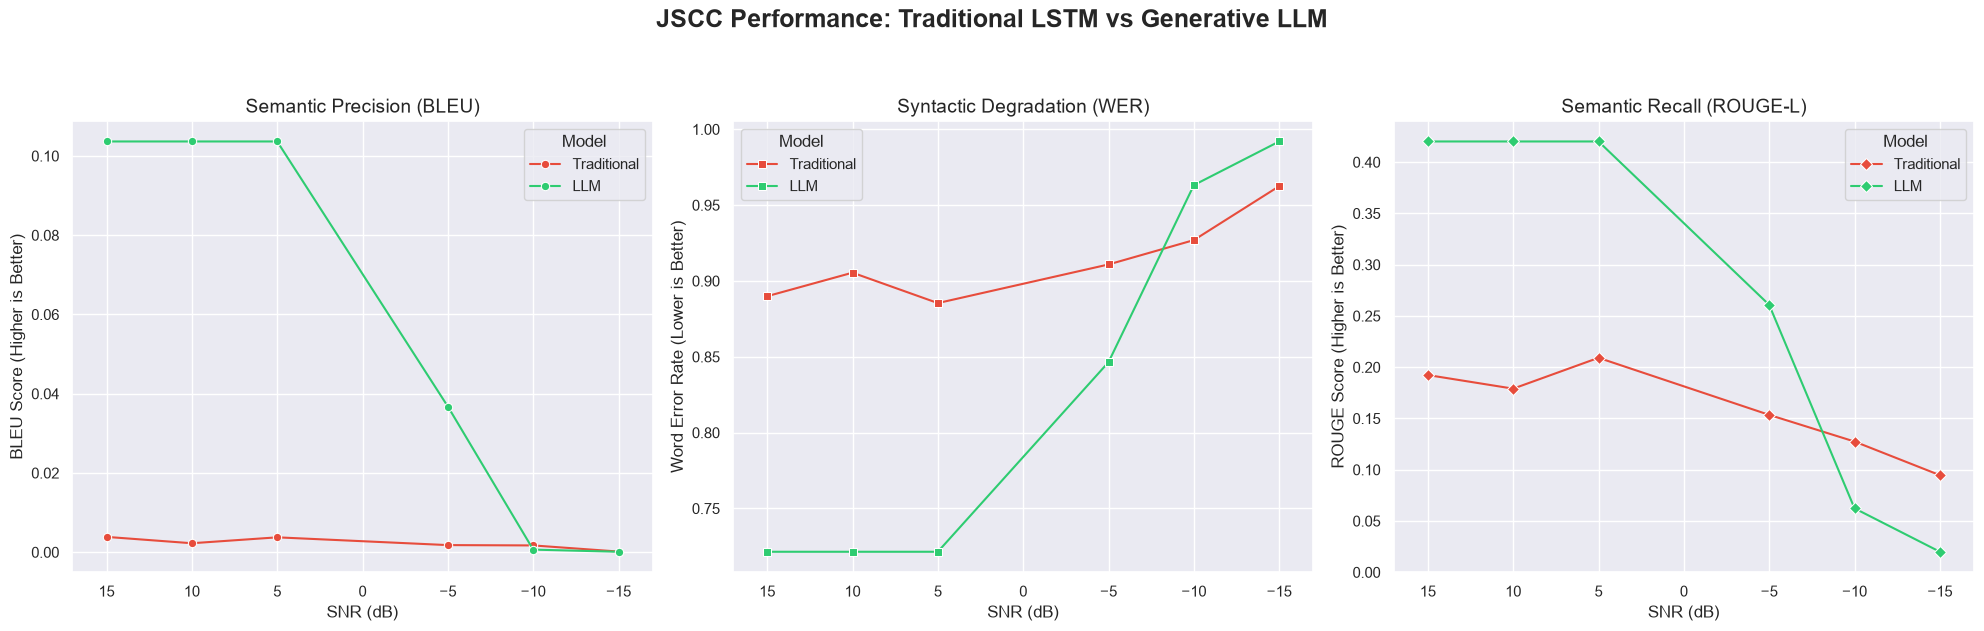

In [20]:
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('JSCC Performance: Traditional LSTM vs Generative LLM', fontsize=18, fontweight='bold', y=1.05)

# Graph 1: BLEU Score
sns.lineplot(data=df_metrics, x='SNR (dB)', y='Avg BLEU', hue='Model', marker='o', ax=axes[0], palette=['#e74c3c', '#2ecc71'])
axes[0].set_xlim(max(snr_levels) + 2, min(snr_levels) - 2) # Clean to Noisy
axes[0].set_title('Semantic Precision (BLEU)', fontsize=14)
axes[0].set_ylabel('BLEU Score (Higher is Better)')

# Graph 2: Word Error Rate
sns.lineplot(data=df_metrics, x='SNR (dB)', y='Avg WER', hue='Model', marker='s', ax=axes[1], palette=['#e74c3c', '#2ecc71'])
axes[1].set_xlim(max(snr_levels) + 2, min(snr_levels) - 2)
axes[1].set_title('Syntactic Degradation (WER)', fontsize=14)
axes[1].set_ylabel('Word Error Rate (Lower is Better)')

# Graph 3: ROUGE Score
sns.lineplot(data=df_metrics, x='SNR (dB)', y='Avg NLP (ROUGE)', hue='Model', marker='D', ax=axes[2], palette=['#e74c3c', '#2ecc71'])
axes[2].set_xlim(max(snr_levels) + 2, min(snr_levels) - 2)
axes[2].set_title('Semantic Recall (ROUGE-L)', fontsize=14)
axes[2].set_ylabel('ROUGE Score (Higher is Better)')

plt.tight_layout()
plt.show()